Supervised Learning - Regression 

In [12]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("heartdata.csv", index_col=0)
df.head()

,biking,smoking,heartdisease
1,30.801246,10.896608,11.769423
2,65.129215,2.219563,2.854081
3,1.959665,17.588331,17.177803
4,44.800196,2.802559,6.816647
5,69.428454,15.974505,4.062224


Check assumptions of a linear regression model, see also Linear Regression Tutorial
Use df.corr() and scipy.stats.pearsonr() for correlation tests


                biking   smoking  heartdisease
biking        1.000000  0.015136     -0.935455
smoking       0.015136  1.000000      0.309131
heartdisease -0.935455  0.309131      1.000000


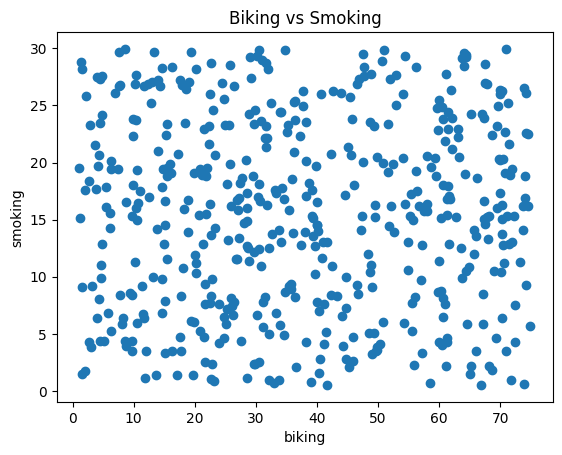

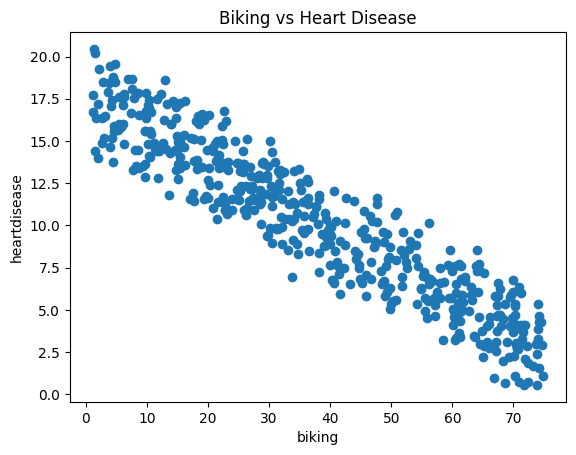

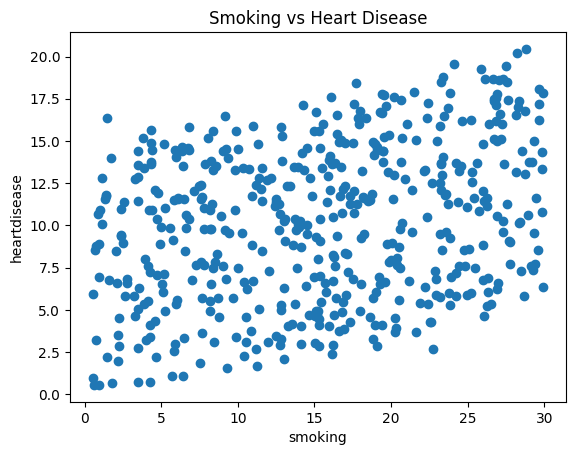

In [17]:
# Check assumptions of a linear regression model, see also Linear Regression Tutorial
# Use df.corr() and scipy.stats.pearsonr() for correlation tests
dfcorr = df.corr()
print(dfcorr)

stats.pearsonr(df["biking"], df["smoking"])

# Use matplotlib.pyplot.scatter() for visualizing relationships
plt.scatter(df["biking"], df["smoking"])
plt.xlabel("biking")
plt.ylabel("smoking")
plt.title("Biking vs Smoking")
plt.show()

# biking vs heartdisease
plt.scatter(df["biking"], df["heartdisease"])
plt.xlabel("biking")
plt.ylabel("heartdisease")
plt.title("Biking vs Heart Disease")
plt.show()

# smoking vs heartdisease
plt.scatter(df["smoking"], df["heartdisease"])
plt.xlabel("smoking")
plt.ylabel("heartdisease")
plt.title("Smoking vs Heart Disease")
plt.show()

statistic = 0.015 — the Pearson r correlation coefficient
Ranges from −1 to +1
0.015 is extremely close to 0 → almost no linear relationship between bike and smoke 
pvalue = 0.736  not significant

No relationship between bike and smoke

Coefficients: [-0.20013305  0.17833391]
Intercept: 14.984657987225845
R^2 Score: 0.9796174523377278


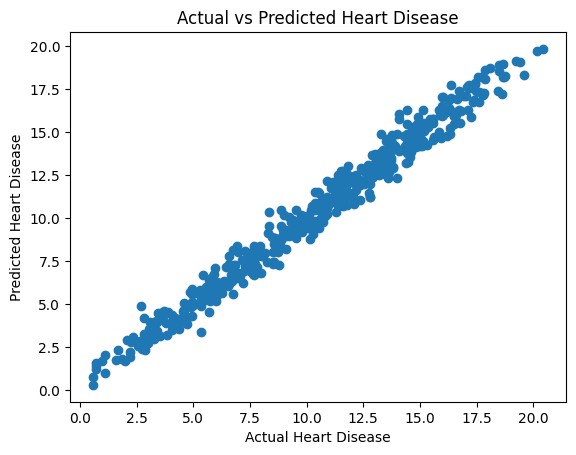

In [20]:
# Fit a linear regression model
# Use LinearRegression from sklearn.linear_model
from sklearn.linear_model import LinearRegression
X = df[["biking", "smoking"]]
y = df["heartdisease"]
model = LinearRegression()
# Fit the model using .fit(X, y)
model.fit(X, y)
# Print the coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluate the model
# Use sklearn.metrics.r2_score() for model performance
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print("R^2 Score:", r2) 

# Use matplotlib.pyplot.scatter() to visualize predictions
plt.scatter(y, y_pred)
plt.xlabel("Actual Heart Disease")
plt.ylabel("Predicted Heart Disease")
plt.title("Actual vs Predicted Heart Disease")
plt.show()

In [21]:

# Train the model using cross-validation
# Use train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
# Fit model on training data and evaluate on test data
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
print("Test R^2 Score:", r2_test)   

Test R^2 Score: 0.9751106638392245
